# **Week2 복습과제**

**1. [ANN]**

**2. [CNN]**

- 데이터는 Week 1 과 같이 MNIST (0-9 숫자 분류) 데이터셋입니다.
- 이때, 우리의 복습과제에서는 0-4 숫자 분류를 위한 데이터 샘플만 사용할 예정입니다
- 아래 코드를 실행시켜 주세요

In [2]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Subset
import random

# Tensor 변환을 위함
transform = transforms.Compose([
    transforms.ToTensor()
])

# MNIST 데이터셋 불러오기
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = MNIST(root='./data', train=False, transform=transform, download=True)

# 무작위로 샘플 인덱스 선택
train_indices = [i for i, label in enumerate(train_dataset.targets) if label in [0, 1, 2, 3, 4]]
test_indices = [i for i, label in enumerate(test_dataset.targets) if label in [0, 1, 2, 3, 4]]

# Subset을 사용하여 샘플링된 데이터셋 생성
train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)


# DataLoader 생성
batch_size = 64  # 배치 크기는 64로 설정 (batch_size를 다르게 실행해보셔도 좋습니다)
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]


In [3]:
# 데이터셋 크기 확인을 위해 해당 셀을 실행시켜 주세요
print(f"Train dataset size: {len(train_subset)}")
print(f"Test dataset size: {len(test_subset)}")

Train dataset size: 30596
Test dataset size: 5139


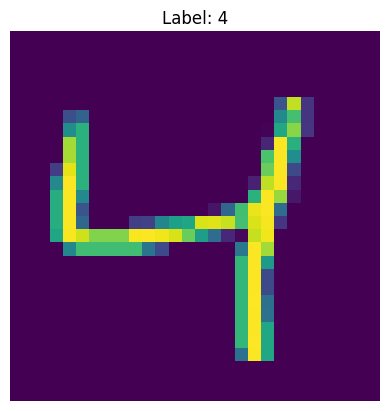

In [4]:
# 데이터셋 중 하나의 이미지를 시각화해보기
import matplotlib.pyplot as plt
import numpy as np

# 데이터셋에서 하나의 샘플 가져오기
image, label = train_subset[1]

# 텐서를 NumPy 배열로 변환
image = image.numpy().squeeze()

# 이미지 출력
plt.imshow(image)  # 이미지 표시
plt.title(f"Label: {label}")  # 레이블 표시
plt.axis("off")  # 축 없애기
plt.show()

<a id="1"></a> <br>
## **1. ANN**

**인공 신경망 (ANN)**

>  로지스틱 회귀는 분류 문제에서 성능이 좋지만, 데이터의 비선형성이 증가하면 모델의 정확도가 감소합니다.

>  따라서, hidden lyaer 에 더 많은 비선형 함수를 추가시켜 모델의 복잡도를 증가시켜 봅시다. 😀

↪ **3개의 hidden layer를 쌓고 다양한 활성화 함수 ReLU, Tanh, ELU 사용해봅시다**


In [5]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn

#### **ANN 모델 생성**

In [6]:
class ANNModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ANNModel, self).__init__()

        # Linear function 1: ____ --> ____  (입력 차원에서 숨겨진 계층으로)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Non-linearity 1 (ReLU 활성화 함수)
        self.relu1 = nn.ReLU()

        # Linear function 2: ____ --> ____  (숨겨진 계층을 한 번 더 통과)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2 (Tanh 활성화 함수 사용)
        self.tanh2 = nn.Tanh()

        # Linear function 3: ____ --> ____  (추가 숨겨진 계층)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 3 (ELU 활성화 함수)
        self.elu3 = nn.ELU()

        # Linear function 4: ____ --> ____  (마지막 출력층)
        self.fc4 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1(out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.tanh2(out)

        # Linear function 3
        out = self.fc3(out)
        # Non-linearity 3
        out = self.elu3(out)

        # Linear function 4
        out = self.fc4(out)  # 마지막 출력층
        return out

In [7]:
# ANN 객체 생성
input_dim = 28*28  # 이미지 크기 (28x28)
hidden_dim = 150  # 하이퍼파라미터 (150으로 설정)
output_dim = 5  # 출력 클래스 개수 (0~4)


model = ANNModel(input_dim,hidden_dim,output_dim)
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss() # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

#### **ANN 모델 학습**

In [8]:
# ANN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트

# 전체 학습
for epoch in range(10):

    # 배치 단위 학습
    for i, (images, labels) in enumerate(train_loader):

        # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
        train = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
        labels = labels  # 텐서 형태 유지

        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        # 모델을 이용해 예측값(outputs) 계산
        outputs = model(train)

        # 손실 계산
        # cross entropy loss를 사용해 예측값과 실제값 비교
        loss = loss_ftn(outputs, labels)

        # Backward propagation - 손실에 대한 기울기 계산
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            # 정확도 계산을 위한 변수 초기화
            correct = 0
            total = 0


            # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
            for images, labels in test_loader:

                test = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                # Forward
                # 예측값 계산
                outputs = model(test)

                # 예측값 중 가장 높은 값을 선택
                predicted = torch.max(outputs.data, 1)[1]

                # 총 샘플 개수
                total += len(labels)

                # 올바르게 예측한 개수
                correct += (predicted == labels).sum()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if count % 500 == 0:
            # 손실 및 정확도 출력
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))

Iteration: 500  Loss: 0.19109894335269928  Accuracy: 96.20549011230469 %
Iteration: 1000  Loss: 0.23619002103805542  Accuracy: 97.15898132324219 %
Iteration: 1500  Loss: 0.18766967952251434  Accuracy: 97.39248657226562 %
Iteration: 2000  Loss: 0.05627961456775665  Accuracy: 97.58708190917969 %
Iteration: 2500  Loss: 0.050258442759513855  Accuracy: 97.7038345336914 %
Iteration: 3000  Loss: 0.08057931065559387  Accuracy: 97.95680236816406 %
Iteration: 3500  Loss: 0.02087591029703617  Accuracy: 98.01517486572266 %
Iteration: 4000  Loss: 0.026235803961753845  Accuracy: 98.2292251586914 %
Iteration: 4500  Loss: 0.10130985826253891  Accuracy: 98.30706024169922 %


#### **ANN 학습 결과**

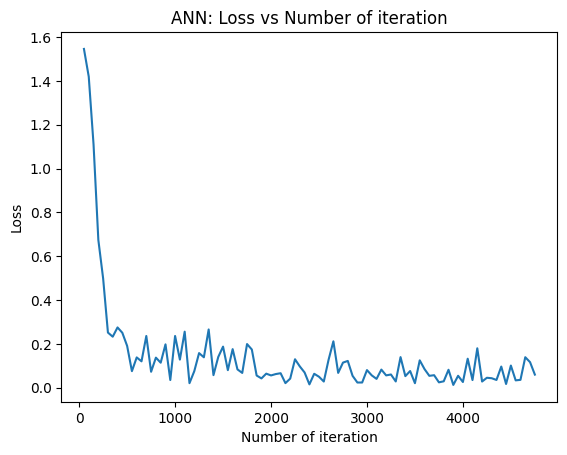

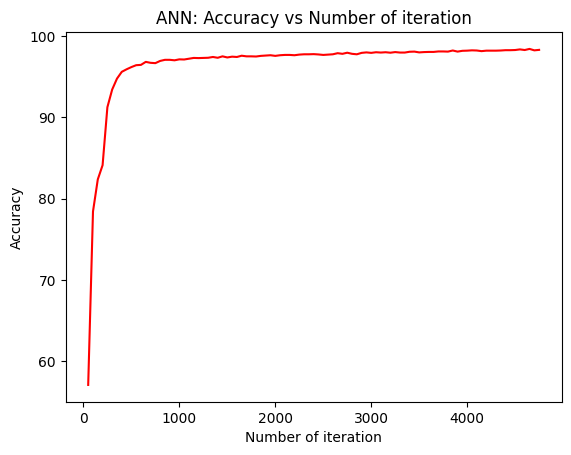

In [9]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 시각화된 모델의 학습 결과를 해석해주세요.** 🤗


- ReLU는 얕은 신경망에서 경사 소실 문제를 완화하고 학습 속도를 높이는 데 도움이 됩니다. Tanh는 출력을 -1과 1 사이로 압축하여 신경망의 안정적인 학습에 기여할 수 있으며, ELU는 ReLU의 장점과 함께 음수 영역에서도 미분 가능하여 학습 성능을 향상시킬 수 있습니다. 이러한 다양한 활성화 함수의 조합이 모델의 표현력을 높여 성능 향상에 긍정적인 영향을 미쳤을 것입니다.

#### **ANN 최적의 하이퍼파라미터 찾기**

1️⃣ **실험 1: Hidden Dimension 최적값 찾기**
- hidden_dim 값을 50-200 사이 값들로 설정하고 모델을 학습
- 각 hidden_dim 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교




2️⃣ **실험 2: Learning Rate 최적값 찾기**

- learning_rate 값을 0.1-0.005 사이 값들로 설정하고 모델을 학습
- 각 learning_rate 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교



**⚠ 이때 epoch 값은 자유롭게 해주셔도 됩니다! **

In [10]:
# 실험 1 hidden_dims=[50-200 사이 값들] 로 학습

# 실험할 hidden_dim 값들
hidden_dims_to_test = [50, 100, 150, 200]

# 결과를 저장할 딕셔너리
results_hidden_dim = {}

num_epochs_exp1 = 5 # 실험 1을 위한 에포크 수 (자유롭게 설정 가능)

for hd in hidden_dims_to_test:
    print(f"\n--- Training with hidden_dim = {hd} ---")

    # 새로운 모델 생성
    model_exp1 = ANNModel(input_dim, hd, output_dim)
    loss_ftn_exp1 = nn.CrossEntropyLoss()
    optimizer_exp1 = torch.optim.SGD(model_exp1.parameters(), lr=learning_rate)

    # 학습을 모니터링하기 위한 변수들
    count_exp1 = 0
    loss_list_exp1 = []
    iteration_list_exp1 = []
    accuracy_list_exp1 = []

    for epoch in range(num_epochs_exp1):
        for i, (images, labels) in enumerate(train_loader):
            train = images.view(-1, 28*28)
            labels = labels

            optimizer_exp1.zero_grad()
            outputs = model_exp1(train)
            loss = loss_ftn_exp1(outputs, labels)
            loss.backward()
            optimizer_exp1.step()

            count_exp1 += 1

            if count_exp1 % 50 == 0:
                correct = 0
                total = 0
                with torch.no_grad():
                    for test_images, test_labels in test_loader:
                        test = test_images.view(-1, 28*28)
                        outputs = model_exp1(test)
                        predicted = torch.max(outputs.data, 1)[1]
                        total += len(test_labels)
                        correct += (predicted == test_labels).sum()

                accuracy = 100 * correct / float(total)
                loss_list_exp1.append(loss.item())
                iteration_list_exp1.append(count_exp1)
                accuracy_list_exp1.append(accuracy)

        print(f'Epoch {epoch+1}/{num_epochs_exp1}, Current Loss: {loss.item():.4f}, Current Accuracy: {accuracy:.2f}%')

    results_hidden_dim[hd] = {
        'loss_list': loss_list_exp1,
        'iteration_list': iteration_list_exp1,
        'accuracy_list': accuracy_list_exp1
    }


--- Training with hidden_dim = 50 ---
Epoch 1/5, Current Loss: 0.0767, Current Accuracy: 95.21%
Epoch 2/5, Current Loss: 0.0332, Current Accuracy: 96.94%
Epoch 3/5, Current Loss: 0.0108, Current Accuracy: 97.30%
Epoch 4/5, Current Loss: 0.3983, Current Accuracy: 97.61%
Epoch 5/5, Current Loss: 0.0442, Current Accuracy: 97.76%

--- Training with hidden_dim = 100 ---
Epoch 1/5, Current Loss: 0.0680, Current Accuracy: 95.64%
Epoch 2/5, Current Loss: 0.0439, Current Accuracy: 96.87%
Epoch 3/5, Current Loss: 0.0041, Current Accuracy: 97.35%
Epoch 4/5, Current Loss: 0.2117, Current Accuracy: 97.65%
Epoch 5/5, Current Loss: 0.0202, Current Accuracy: 97.72%

--- Training with hidden_dim = 150 ---
Epoch 1/5, Current Loss: 0.2429, Current Accuracy: 96.03%
Epoch 2/5, Current Loss: 0.2681, Current Accuracy: 97.18%
Epoch 3/5, Current Loss: 0.0055, Current Accuracy: 97.41%
Epoch 4/5, Current Loss: 0.0069, Current Accuracy: 97.76%
Epoch 5/5, Current Loss: 0.0034, Current Accuracy: 97.88%

--- Traini

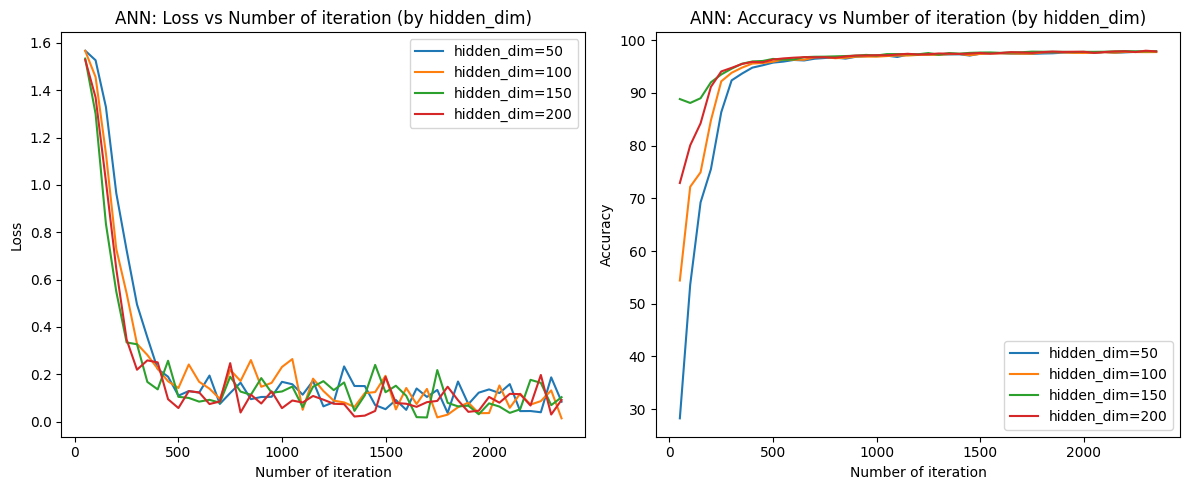

In [11]:

# 실험 1 모델 학습 결과 시각화
plt.figure(figsize=(12, 5))

# Loss 시각화
plt.subplot(1, 2, 1) # 1행 2열 중 첫 번째
for hd, result in results_hidden_dim.items():
    plt.plot(result['iteration_list'], result['loss_list'], label=f'hidden_dim={hd}')
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration (by hidden_dim)")
plt.legend()

# Accuracy 시각화
plt.subplot(1, 2, 2) # 1행 2열 중 두 번째
for hd, result in results_hidden_dim.items():
    plt.plot(result['iteration_list'], result['accuracy_list'], label=f'hidden_dim={hd}')
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration (by hidden_dim)")
plt.legend()

plt.tight_layout()
plt.show()

**해당 셀의 마크 다운을 풀고 hidden dimension 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**

  - **낮은 hidden_dim**: 뉴런 수가 적으면 모델이 데이터의 복잡한 패턴을 학습하기 어려워 과소적합(Underfitting)이 발생할 수 있습니다. 그래프에서 손실이 충분히 감소하지 않거나 정확도가 낮게 유지되는 형태로 나타날 수 있습니다.
  - **높은 hidden_dim**: 뉴런 수가 많으면 모델의 표현력이 증가하여 복잡한 패턴도 잘 학습할 수 있습니다. 이 경우 손실이 더 낮게 떨어지고 정확도가 높아질 수 있습니다. 하지만 너무 높으면 모델이 학습 데이터에 과하게 맞춰져 과적합(Overfitting)이 발생할 위험이 있습니다. 과적합된 모델은 학습 데이터에는 높은 정확도를 보이지만, 새로운 데이터(테스트 데이터)에서는 성능이 떨어질 수 있습니다.
  - **최적의 hidden_dim**: 일반적으로 중간 정도의 hidden_dim에서 가장 좋은 성능을 보입니다. 이는 모델이 충분한 표현력을 가지면서도 과적합을 피할 수 있는 균형점을 찾기 때문입니다. 시각화된 그래프를 통해 어떤 `hidden_dim` 값에서 Loss가 가장 낮고 Accuracy가 가장 높은지, 그리고 그 추세가 안정적인지를 확인하여 최적의 값을 유추할 수 있습니다.

In [20]:
# 실험 2 learning_rates=[0.1-0.005 사이 값들] 로 학습

# 실험할 learning_rates 값들
learning_rates_to_test = [0.1, 0.05, 0.01, 0.005] # 학습률에 적합한 값으로 수정

# 결과를 저장할 딕셔너리
results_learning_rates = {}
# hidden_dim은 실험 1에서 찾은 최적값 또는 적절한 값으로 고정 (예: 150)
hd = 150
num_epochs_exp1 = 5 # 실험 2를 위한 에포크 수 (자유롭게 설정 가능)

for lr in learning_rates_to_test:
    print(f"\n--- Training with learning_rate = {lr} ---")

    # 새로운 모델 생성
    model_exp1 = ANNModel(input_dim, hd, output_dim)
    loss_ftn_exp1 = nn.CrossEntropyLoss()
    # 옵티마이저에 현재 반복의 lr 값을 전달
    optimizer_exp1 = torch.optim.SGD(model_exp1.parameters(), lr=lr)

    # 학습을 모니터링하기 위한 변수들
    count_exp1 = 0
    loss_list_exp1 = []
    iteration_list_exp1 = []
    accuracy_list_exp1 = []

    for epoch in range(num_epochs_exp1):
        for i, (images, labels) in enumerate(train_loader):
            train = images.view(-1, 28*28)
            labels = labels

            optimizer_exp1.zero_grad()
            outputs = model_exp1(train)
            loss = loss_ftn_exp1(outputs, labels)
            loss.backward()
            optimizer_exp1.step()

            count_exp1 += 1

            if count_exp1 % 50 == 0:
                correct = 0
                total = 0
                with torch.no_grad():
                    for test_images, test_labels in test_loader:
                        test = test_images.view(-1, 28*28)
                        outputs = model_exp1(test)
                        predicted = torch.max(outputs.data, 1)[1]
                        total += len(test_labels)
                        correct += (predicted == test_labels).sum()

                accuracy = 100 * correct / float(total)
                loss_list_exp1.append(loss.item())
                iteration_list_exp1.append(count_exp1)
                accuracy_list_exp1.append(accuracy)

        print(f'Epoch {epoch+1}/{num_epochs_exp1}, Current Loss: {loss.item():.4f}, Current Accuracy: {accuracy:.2f}%')

    results_learning_rates[lr] = { # results_hidden_dim 대신 results_learning_rates에 저장
        'loss_list': loss_list_exp1,
        'iteration_list': iteration_list_exp1,
        'accuracy_list': accuracy_list_exp1
    }


--- Training with learning_rate = 0.1 ---
Epoch 1/5, Current Loss: 0.0086, Current Accuracy: 97.55%
Epoch 2/5, Current Loss: 0.0099, Current Accuracy: 98.50%
Epoch 3/5, Current Loss: 0.0109, Current Accuracy: 98.64%
Epoch 4/5, Current Loss: 0.0065, Current Accuracy: 98.97%
Epoch 5/5, Current Loss: 0.0002, Current Accuracy: 99.05%

--- Training with learning_rate = 0.05 ---
Epoch 1/5, Current Loss: 0.4592, Current Accuracy: 97.12%
Epoch 2/5, Current Loss: 0.0158, Current Accuracy: 97.72%
Epoch 3/5, Current Loss: 0.0402, Current Accuracy: 98.11%
Epoch 4/5, Current Loss: 0.0034, Current Accuracy: 98.38%
Epoch 5/5, Current Loss: 0.0029, Current Accuracy: 98.79%

--- Training with learning_rate = 0.01 ---
Epoch 1/5, Current Loss: 0.4306, Current Accuracy: 90.29%
Epoch 2/5, Current Loss: 0.0149, Current Accuracy: 96.19%
Epoch 3/5, Current Loss: 0.1739, Current Accuracy: 96.87%
Epoch 4/5, Current Loss: 0.1106, Current Accuracy: 97.31%
Epoch 5/5, Current Loss: 0.1099, Current Accuracy: 97.35%

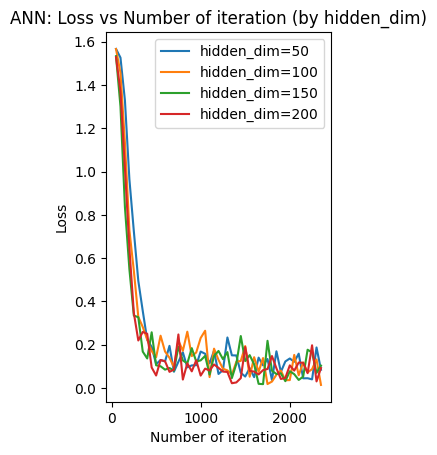

In [21]:
import matplotlib.pyplot as plt

# 실험 2 모델 학습 결과 시각화
plt.figure(figsize=(12, 5))

# Loss 시각화
plt.subplot(1, 2, 1) # 1행 2열 중 첫 번째
for lr, result in results_learning_rates.items():
    plt.plot(result['iteration_list'], result['loss_list'], label=f'learning_rate={lr}')
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration (by learning_rate)")
plt.legend()

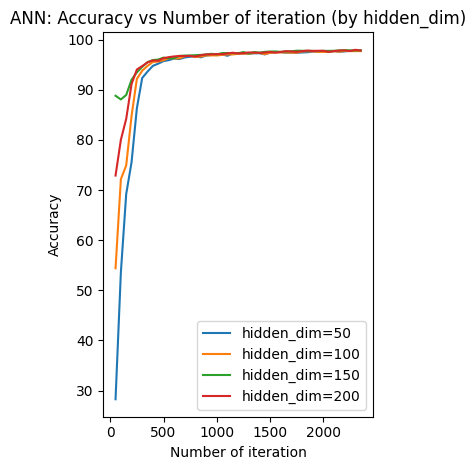

In [22]:
import matplotlib.pyplot as plt

# 실험 2 모델 학습 결과 시각화
# Accuracy 시각화
plt.subplot(1, 2, 2) # 1행 2열 중 두 번째
for lr, result in results_learning_rates.items():
    plt.plot(result['iteration_list'], result['accuracy_list'], label=f'learning_rate={lr}')
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration (by learning_rate)")
plt.legend()

plt.tight_layout()
plt.show()

**해당 셀의 마크 다운을 풀고 learning rate 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**

*   **높은 학습률 (예: 0.1)**:
    *   **장점**: 매우 빠른 속도로 손실을 줄이고 정확도를 높일 수 있습니다. 초기 학습이 매우 빠르게 진행됩니다.
    *   **단점**: 너무 높으면 최적점을 건너뛰어 발산하거나, 최적점 주변에서 진동하여 수렴하지 못할 수 있습니다. 현재 실험에서는 0.1이 높은 학습률임에도 불구하고 매우 좋은 성능(99.05%)을 보이며 빠르게 수렴했습니다.


*   **낮은 학습률 (예: 0.01, 0.005)**:
    *   **장점**: 최적점을 더 정확하게 찾아낼 가능성이 있습니다. 발산할 위험이 적습니다.
    *   **단점**: 학습 속도가 매우 느려 학습에 필요한 시간이 길어집니다. 손실이 천천히 감소하고, 충분한 Epoch을 거치지 않으면 최적 성능에 도달하지 못할 수 있습니다. 0.01과 0.005에서는 Epoch 5까지 비교적 낮은 정확도(각각 97.35%, 96.59%)와 높은 손실을 보이며 아직 충분히 수렴하지 못한 것을 확인할 수 있습니다.

<a id="1"></a> <br>
## **2. CNN**
> CNN은 이미지 분류에 적합한 모델로, kernel을 이용해 feature map을 생성합니다

**↪ 2개의 합성곱 계층을 쌓고, 활성화 함수로 ReLU를 사용하며,Max Pooling layer를 적용해봅시다.**

#### **CNN 모델 생성**

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim

# CNN Model 정의
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # 합성곱 계층 1 (Conv Layer 1)
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)  # kernel size를 2로 설정

        # 합성곱 계층 2 (Conv Layer 2)
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2) # kernel size를 2로 설정

        # Fully Connected Layer
        self.fc1 = nn.Linear(32 * 4 * 4, 5)  # 입력 차원 및 출력 차원 지정

    def forward(self, x):
        # 합성곱 계층 1 + 활성화 함수
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max Pooling 1
        out = self.maxpool1(out)

        # 합성곱 계층 2 + 활성화 함수
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max Pooling 2
        out = self.maxpool2(out)

        # feature map을 flatten하게
        out = out.view(out.size(0), -1)

        # 완전 연결 계층
        out = self.fc1(out)

        return out

In [16]:
# CNN 객체 생성
model = CNNModel()
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss()  # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
optimizer = optim.SGD(model.parameters(), lr=0.01)  # 학습률을 자유롭게 설정해주세요

#### **CNN 모델 학습**

In [17]:
# CNN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트
num_epochs = 20  # 학습할 에포크 수 설정 -> 자유롭게 설정해주셔도 됩니다

for epoch in range(num_epochs):
    running_loss = 0.0  # 에포크별 손실 초기화

    for images, labels in train_loader:
        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # 손실 계산
        loss = loss_ftn(outputs, labels)

        # Backward
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 손실 누적
        running_loss += loss.item()
        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            correct = 0
            total = 0

            with torch.no_grad():  # 평가
                for images, labels in test_loader:
                    # 모델 예측 수행
                    outputs = model(images)

                    # 가장 확률이 높은 클래스 선택
                    predicted = torch.max(outputs.data, 1)[1]

                    # 총 샘플 수 및 올바른 예측 개수 누적
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

    # 매 에포크마다 평균 손실 출력
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

Epoch 1, Loss: 0.5334327642597834
Epoch 2, Loss: 0.12239064860482368
Epoch 3, Loss: 0.0951402657257008
Epoch 4, Loss: 0.07854504523908677
Epoch 5, Loss: 0.0688963848835009
Epoch 6, Loss: 0.06075138559794376
Epoch 7, Loss: 0.05351009031384406
Epoch 8, Loss: 0.04858879735187816
Epoch 9, Loss: 0.04468649891941538
Epoch 10, Loss: 0.042135182857544536
Epoch 11, Loss: 0.03947643148795447
Epoch 12, Loss: 0.03702248036589217
Epoch 13, Loss: 0.035373744106290586
Epoch 14, Loss: 0.033430384742028016
Epoch 15, Loss: 0.032478040704354914
Epoch 16, Loss: 0.031075941549788086
Epoch 17, Loss: 0.02986172455074246
Epoch 18, Loss: 0.02848304054818441
Epoch 19, Loss: 0.027813950730225225
Epoch 20, Loss: 0.026989146339170447


#### **CNN 학습 결과**

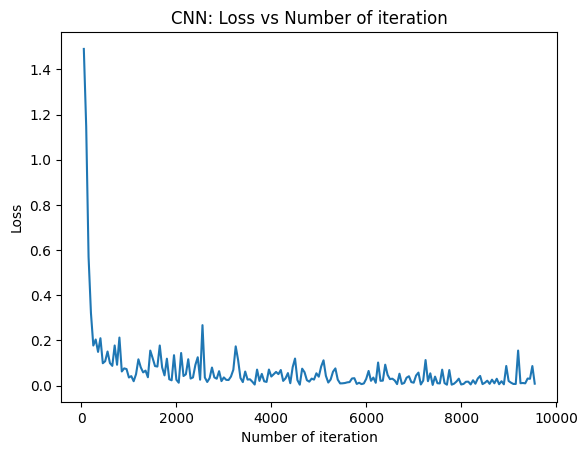

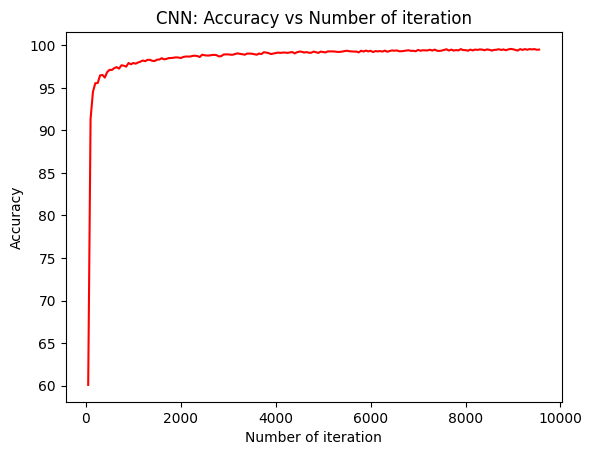

In [18]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN: Accuracy vs Number of iteration")
plt.show()

 **해당 셀의 마크 다운을 풀고 MNIST 데이터셋에서 ANN, CNN의 학습 결과 비교와 함께 두 모델에 대해 각각 짧게 소개해주세요.** 🤗



---
**[답변]**

*  CNN은 ANN과 달리 여러 특징을 추출하고 그 특징들로 다시 학습시키는 것이므로 객체의 공간적 특징을 보존하는 특성이 있습니다. 따라서 MNIST 데이터셋과 같은 이미지 데이터 분류에서 강점을 드러냅니다.